In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import os 

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


In [15]:
path = '../data/employee_performance_workload_attrition.csv'
data = pd.read_csv(path)
print("Data loaded successfully!")

Data loaded successfully!


In [16]:
data.head()

,employee_id,department,role_level,monthly_salary,avg_weekly_hours,projects_handled,performance_rating,absences_days,job_satisfaction,attrition
0,1,HR,Junior,81750,55,1,1,17,1,Yes
1,2,Engineering,Senior,58140,36,2,4,13,1,Yes
2,3,Finance,Mid,37747,61,2,2,20,5,No
3,4,Finance,Senior,81993,36,4,1,17,2,Yes
4,5,Sales,Senior,45439,53,5,5,5,1,No


In [17]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2800 entries, 0 to 2799
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   employee_id         2800 non-null   int64 
 1   department          2800 non-null   object
 2   role_level          2800 non-null   object
 3   monthly_salary      2800 non-null   int64 
 4   avg_weekly_hours    2800 non-null   int64 
 5   projects_handled    2800 non-null   int64 
 6   performance_rating  2800 non-null   int64 
 7   absences_days       2800 non-null   int64 
 8   job_satisfaction    2800 non-null   int64 
 9   attrition           2800 non-null   object
dtypes: int64(7), object(3)
memory usage: 218.9+ KB


**Dataset Overview**

* Shape: 2,800 employees × 10 features

* Target: attrition (binary: Yes/No employee left)

* Missing values: We dont have any missing, non and Null values

* first column is the `UniqeId` for my project

In [18]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
employee_id,2800.0,1400.500000,808.434702,1.0,700.75,1400.5,2100.25,2800.0
monthly_salary,2800.0,74492.075000,25899.209391,30006.0,51665.00,74587.5,97249.50,119977.0
avg_weekly_hours,2800.0,49.842500,8.980976,35.0,42.00,50.0,57.00,65.0
projects_handled,2800.0,4.519286,2.286778,1.0,3.00,4.0,7.00,8.0
performance_rating,2800.0,2.960714,1.404794,1.0,2.00,3.0,4.00,5.0
absences_days,2800.0,9.995000,6.056656,0.0,5.00,10.0,15.00,20.0
job_satisfaction,2800.0,2.995357,1.414332,1.0,2.00,3.0,4.00,5.0


In [19]:
for col in data.columns:
    print(f"Unique values in '{col}': {data[col].nunique()}")

Unique values in 'employee_id': 2800
Unique values in 'department': 6
Unique values in 'role_level': 3
Unique values in 'monthly_salary': 2753
Unique values in 'avg_weekly_hours': 31
Unique values in 'projects_handled': 8
Unique values in 'performance_rating': 5
Unique values in 'absences_days': 21
Unique values in 'job_satisfaction': 5
Unique values in 'attrition': 2


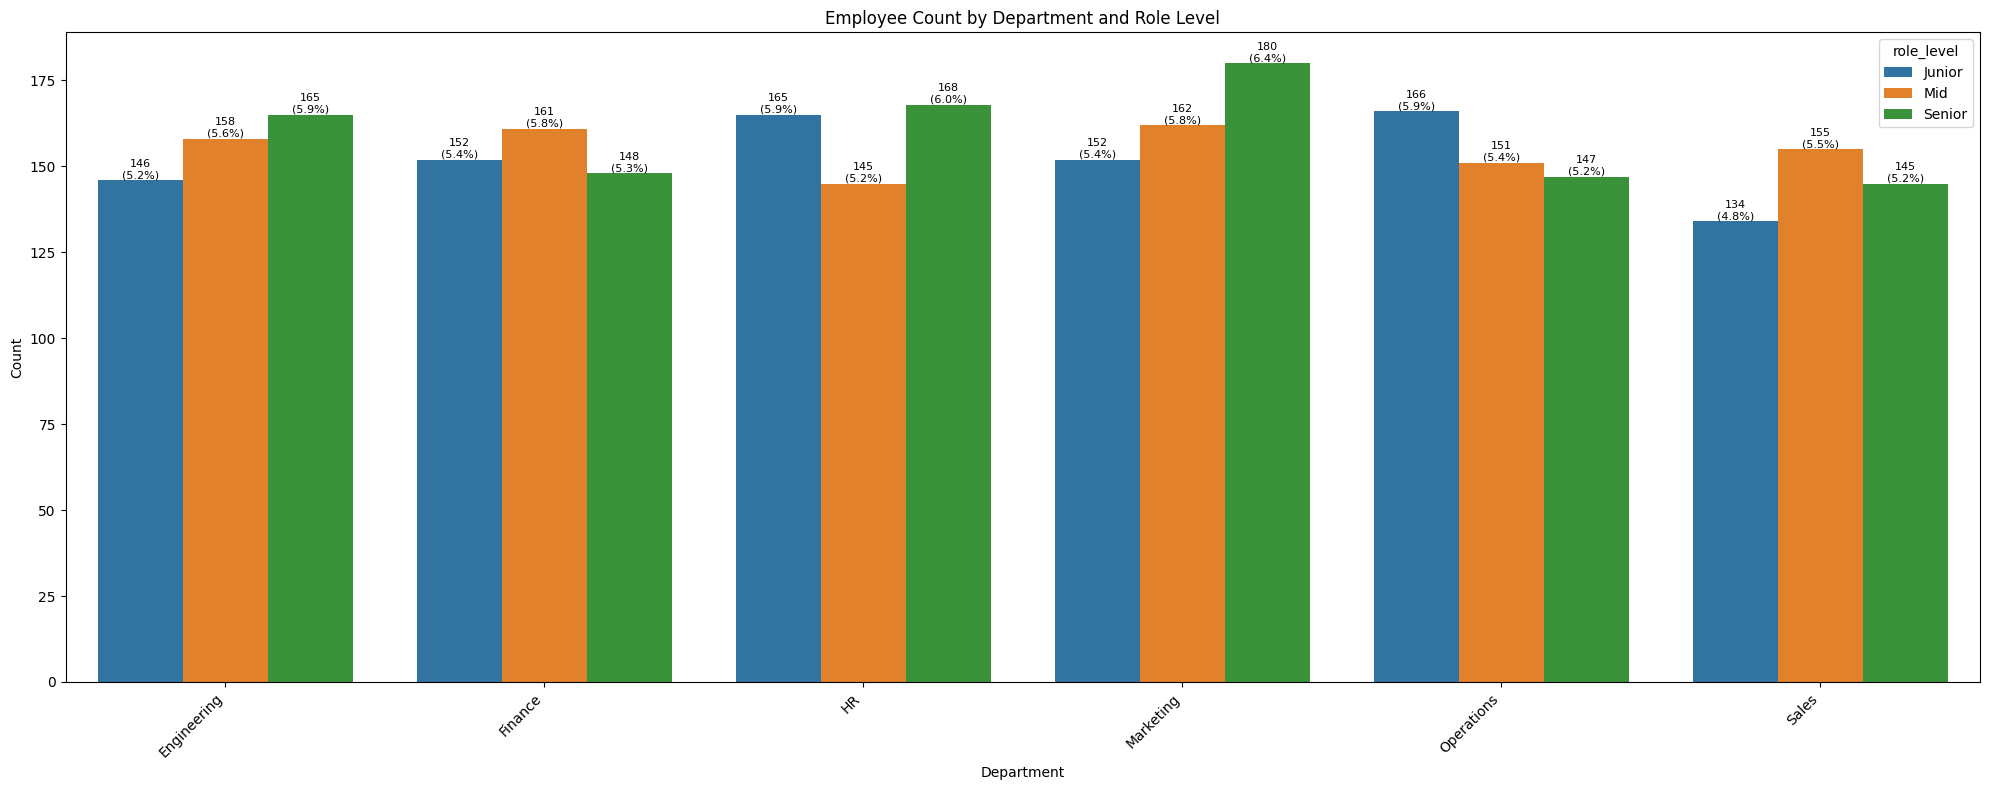

In [37]:
dep_rol = data.groupby(['department', 'role_level']).size().reset_index(name='Count')
total = dep_rol.groupby('department')['Count'].transform('sum')
dep_rol['Percentage'] = (dep_rol['Count'] / total * 100).round(1)

fig, ax = plt.subplots(figsize=(20, 8))
sns.barplot(x='department', y='Count', hue='role_level', data=dep_rol, ax=ax)

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f'{height:.0f}\n({height/dep_rol["Count"].sum()*100:.1f}%)',
            (p.get_x() + p.get_width() / 2., height),
            ha='center', va='bottom', fontsize=8, color='black'
        )

plt.title("Employee Count by Department and Role Level")
plt.xlabel("Department")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()